In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('AmesHousing.csv')

1 -  Histograms / KDE.

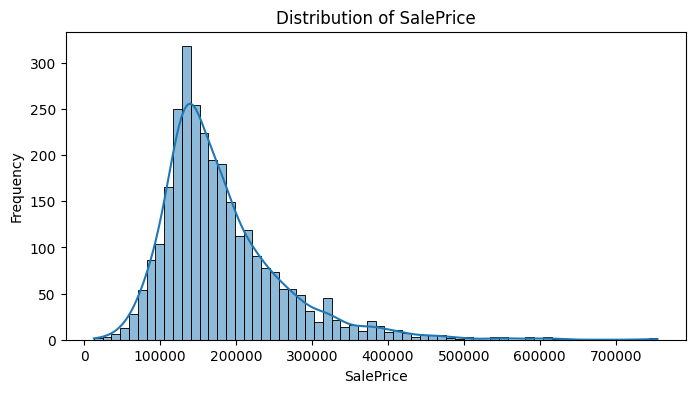

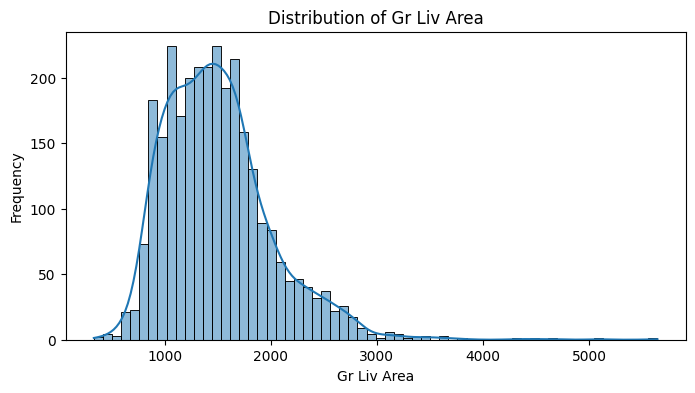

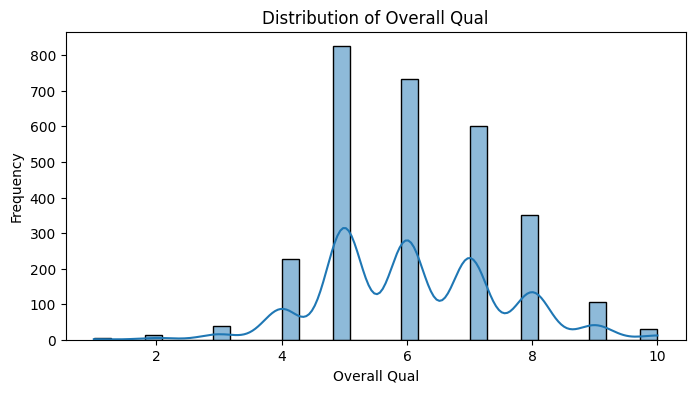

In [11]:
features = ['SalePrice', 'Gr Liv Area', 'Overall Qual']
# SalePrice: It's Right-Skewed. most houses are in the middle price range, but there are a few very expensive houses that pull the 'tail' to the right.
# Gr Liv Area: This distribution is also Skewed to the right. many houses have a similar size but some huge houses make the shape look less symmetric."
# Overall Qual: Overall Qual looks more Symmetric and follows a bell curve. most houses have a quality score of 5 or 6, which is the average.

# Making a loop to draw them one below the other.
for feature in features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()
# These histograms show that while 'Overall Quality' follows a discrete symmetric distribution, both 'SalePrice' and 'Gr Liv Area' are right-skewed. this indicates that most houses fall into the mid-to-lower price and size ranges.

2 -  Grouped boxplots.

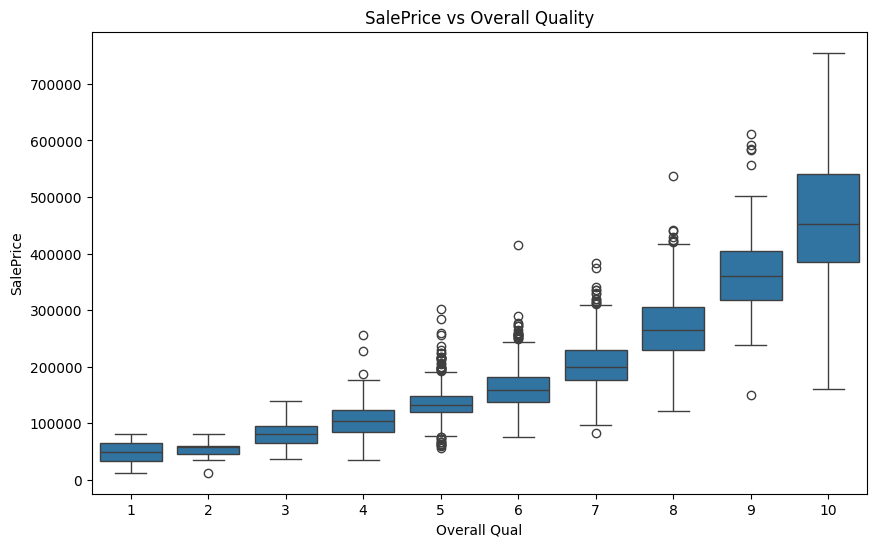

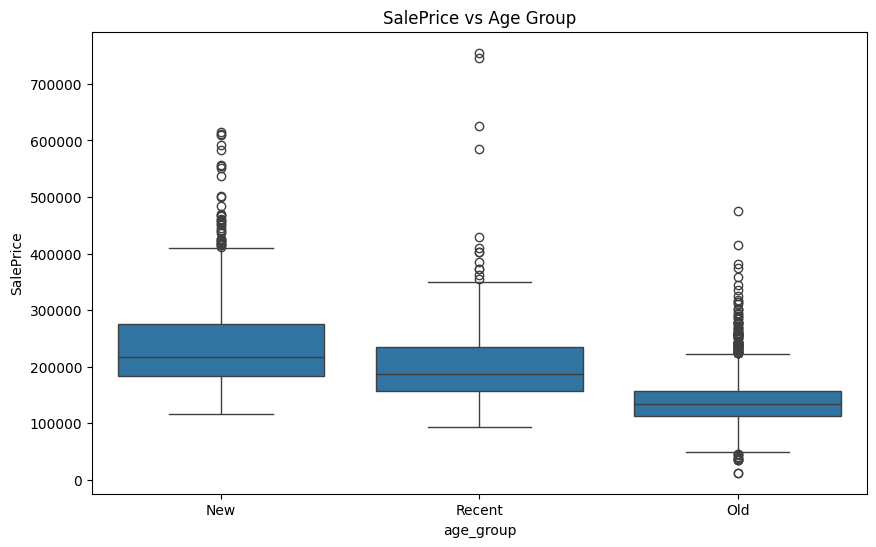

In [12]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Overall Qual', y='SalePrice', data=df)
plt.title('SalePrice vs Overall Quality')
plt.show()
# The boxplot shows that as quality increases, the SalePrice goes up significantly. this means quality is a very strong predictor for house prices.

#----------------------------------------------
# This from last file because it's require the new feature that I was create it.
#----------------------------------------------
df['house_age'] = df['Yr Sold'] - df['Year Built']

bins = [0, 10, 30, 150]
group_names = ['New', 'Recent', 'Old']
#----------------------------------------------

df['age_group'] = pd.cut(df['house_age'], bins=bins, labels=group_names)
plt.figure(figsize=(10, 6))
sns.boxplot(x='age_group', y='SalePrice', data=df, order=['New', 'Recent', 'Old'])
plt.title('SalePrice vs Age Group')
plt.show()
# The boxplot shows that new houses have higher median prices compared to 'Recent' and 'Old' houses. This confirms that the age feature I created is useful for the model.

3 - Correlation heatmap.

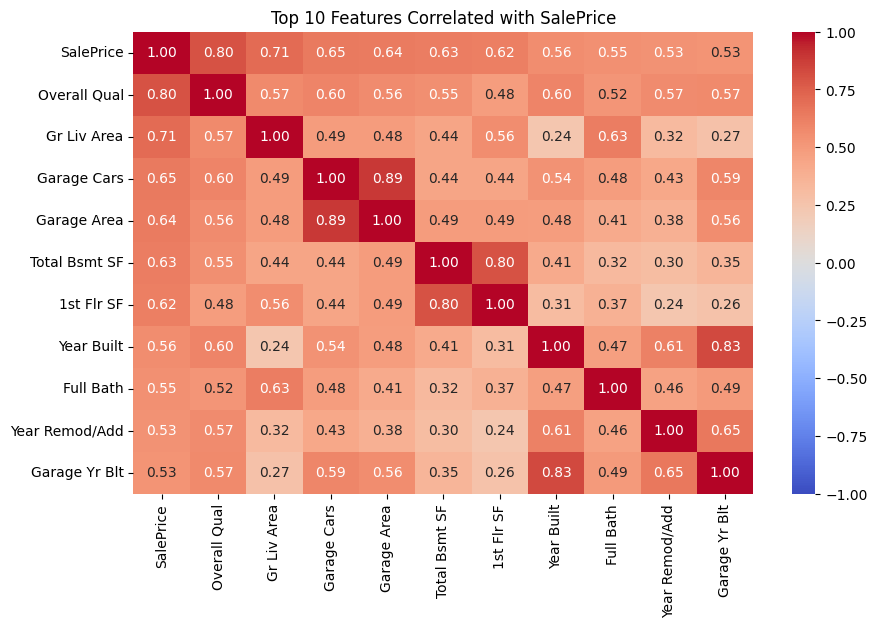

In [13]:
corr_matrix = df.corr(numeric_only=True)

# Top 10 Selection (arranged from largest to smallest)
top_10_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(11).index

plt.figure(figsize=(10, 6))
sns.heatmap(df[top_10_features].corr(numeric_only=True), 
            annot=True,      # To show the numbers inside the boxes
            cmap='coolwarm', # Gradient from blue to red
            fmt=".2f", 
            vmin=-1, 
            vmax=1)

plt.title('Top 10 Features Correlated with SalePrice')
plt.show()
# This helps me focus on the most important variables like Quality and Living Area, which have the strongest impact on the house price.

4 - Scatter plot.

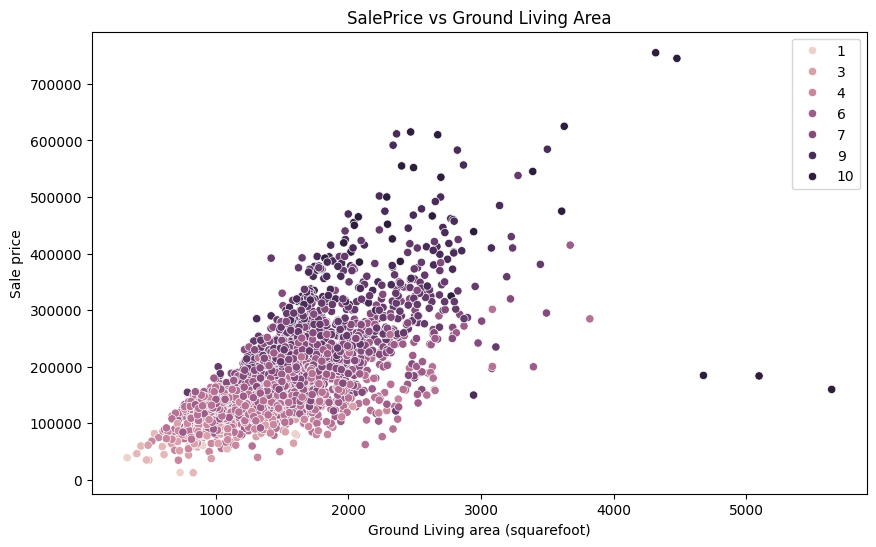

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Gr Liv Area', y='SalePrice', hue='Overall Qual', data=df)
plt.title('SalePrice vs Ground Living Area')
plt.xlabel('Ground Living area (squarefoot)')
plt.ylabel('Sale price')
plt.legend()
plt.show()
#This scatter plot shows that while bigger houses usually cost more, 'Overall Quality' is a huge factor. 

5 - Groupby summary.

In [15]:
# Calculates average price per group.
age_summary = df.groupby('age_group')['SalePrice'].mean().sort_values(ascending=False)

# Show result
print('Mean SalePrice by Age Group:')
print(age_summary)

highest = age_summary.index[0] # Finds the highest priced category.
lowest = age_summary.index[-1] # Finds the lowest priced category.

print(f"The highest priced group is: {highest}")

print(f"The Lowest priced group is: {lowest}")
# It confirmed to us with figures that there is a large price gap between new and old houses (almost double) and this proves that our division of categories was correct and logical for building the model.

Mean SalePrice by Age Group:
age_group
New       240544.375821
Recent    205159.767442
Old       139528.306412
Name: SalePrice, dtype: float64
The highest priced group is: New
The Lowest priced group is: Old


C:\Users\Mohnnad\AppData\Local\Temp\ipykernel_13660\4198996232.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_summary = df.groupby('age_group')['SalePrice'].mean().sort_values(ascending=False)
